In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    roc_auc_score,
    f1_score
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [42]:
data_path= "loan_data.csv"
df = pd.read_csv(data_path)
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [43]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000,4.500e+04,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000,45000.000
mean,27.764,8.032e+04,5.410,9583.158,11.007,0.140,5.867,632.609,0.222
std,6.045,8.042e+04,6.064,6314.887,2.979,0.087,3.880,50.436,0.416
min,20.000,8.000e+03,0.000,500.000,5.420,0.000,2.000,390.000,0.000
25%,24.000,4.720e+04,1.000,5000.000,8.590,0.070,3.000,601.000,0.000
50%,26.000,6.705e+04,4.000,8000.000,11.010,0.120,4.000,640.000,0.000
75%,30.000,9.579e+04,8.000,12237.250,12.990,0.190,8.000,670.000,0.000
max,144.000,7.201e+06,125.000,35000.000,20.000,0.660,30.000,850.000,1.000


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [45]:
print("="*70)
print("DATA QUALITY ASSESSMENT")
print("="*70)

# Missing values
missing = df.isnull().sum()
print(f"\n✅ Missing Values: {missing.sum()} (Expected: 0)")
if missing.sum() > 0:
    print("\n⚠️ Columns with missing values:")
    print(missing[missing > 0])
else:
    print("   ✓ All 2,000 records are complete!")

# Duplicate rows
duplicates = df.duplicated().sum()
print(f"\n✅ Duplicate Rows: {duplicates} (Expected: 0)")

# Target distribution
print(f"\n✅ Loan status Distribution:")
print(df['loan_status'].value_counts())
print(f"\nPercentages:")
print(df['loan_status'].value_counts(normalize=True) * 100)
print(f"\n✓ Balanced classes: 45% Low, 40% Medium, 15% High")



DATA QUALITY ASSESSMENT

✅ Missing Values: 0 (Expected: 0)
   ✓ All 2,000 records are complete!

✅ Duplicate Rows: 0 (Expected: 0)

✅ Loan status Distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Percentages:
loan_status
0    77.778
1    22.222
Name: proportion, dtype: float64

✓ Balanced classes: 45% Low, 40% Medium, 15% High


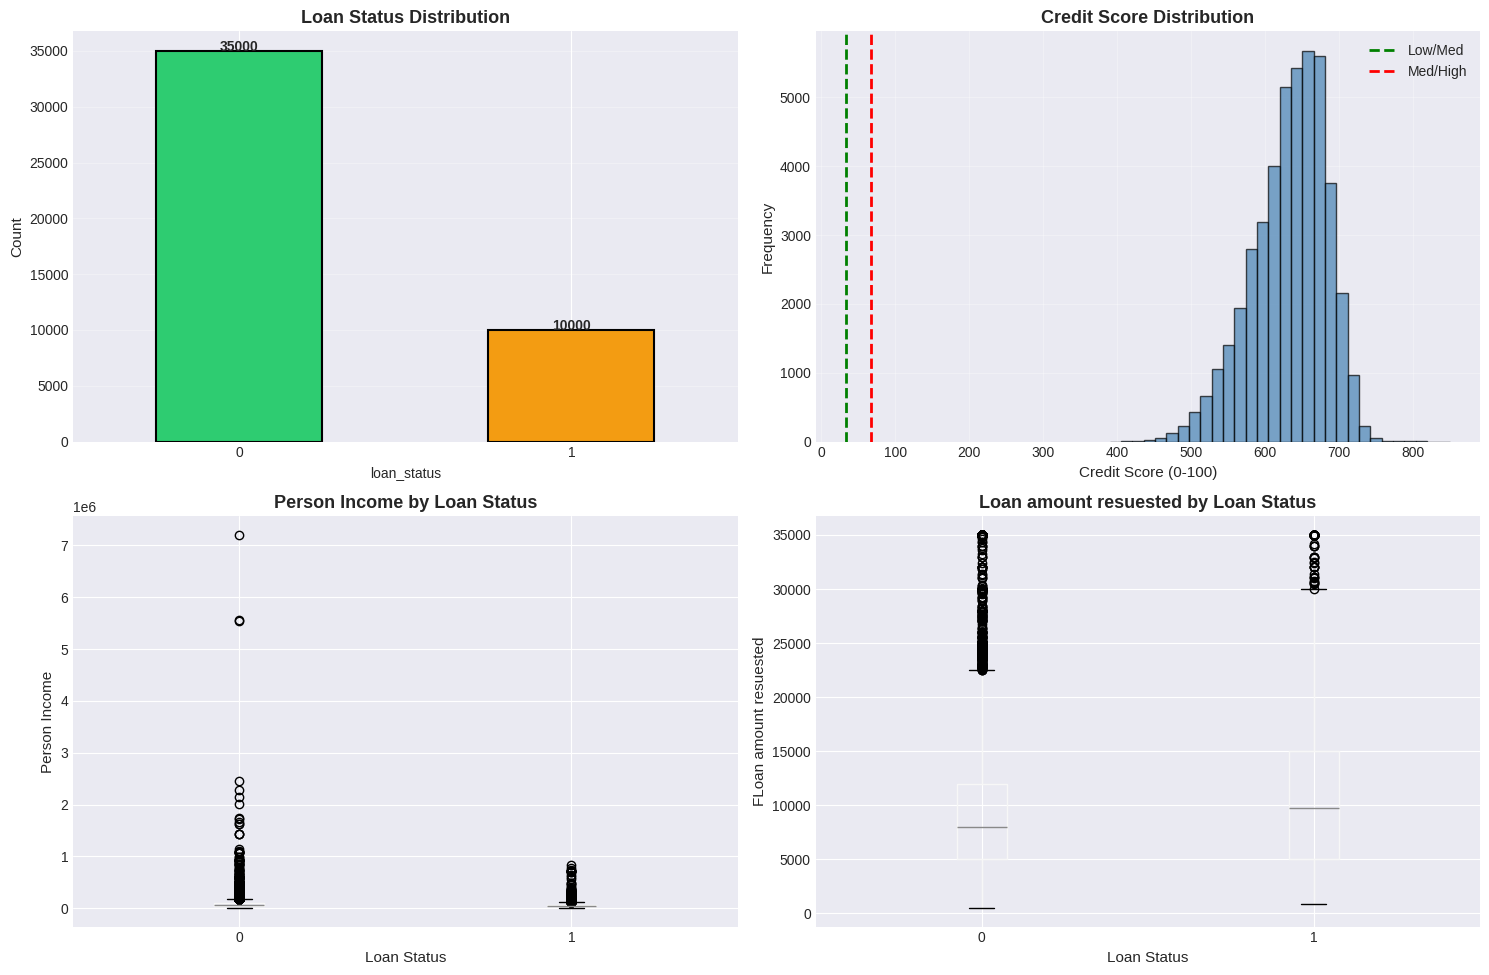

✅ Key Observations:
   • Balanced distribution across loan status categories
   • Clear correlation between person income and loan status
   • Fatigue score strongly predicts loan status


In [46]:


# Burnout risk distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Burnout risk bar chart
loan_status_count = df['loan_status'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
loan_status_count.plot(kind='bar', ax=axes[0, 0], color=colors, edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Loan Status Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(loan_status_count):
    axes[0, 0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# 2. Burnout score histogram
axes[0, 1].hist(df['credit_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(33.33, color='green', linestyle='--', linewidth=2, label='Low/Med')
axes[0, 1].axvline(66.66, color='red', linestyle='--', linewidth=2, label='Med/High')
axes[0, 1].set_title('Credit Score Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Credit Score (0-100)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Person Income by loan_status
df.boxplot(column='person_income', by='loan_status', ax=axes[1, 0])
axes[1, 0].set_title('Person Income by Loan Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Loan Status', fontsize=11)
axes[1, 0].set_ylabel('Person Income', fontsize=11)
axes[1, 0].get_figure().suptitle('')

# 4. Fatigue score by burnout risk
df.boxplot(column='loan_amnt', by='loan_status', ax=axes[1, 1])
axes[1, 1].set_title('Loan amount resuested by Loan Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Loan Status', fontsize=11)
axes[1, 1].set_ylabel('FLoan amount resuested', fontsize=11)
axes[1, 1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

print("✅ Key Observations:")
print("   • Balanced distribution across loan status categories")
print("   • Clear correlation between person income and loan status")
print("   • Fatigue score strongly predicts loan status")



In [47]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df['person_gender'] = le.fit_transform(df['person_gender'])
df['previous_loan_defaults_on_file'] = le.fit_transform(df['previous_loan_defaults_on_file'])


df = pd.get_dummies(df, columns=['person_education', 'person_home_ownership', 'loan_intent'], drop_first=True)



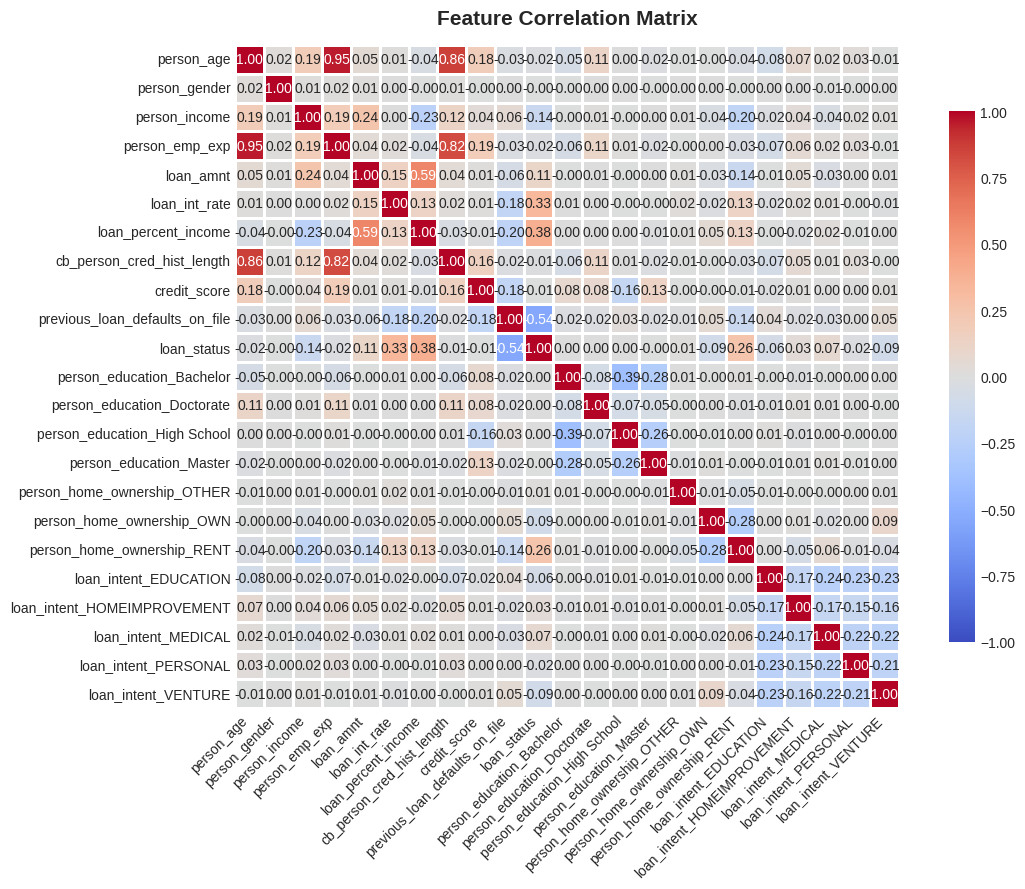


🔍 Top Correlations with Credit Score:
person_emp_exp                    1.862e-01
person_age                        1.784e-01
cb_person_cred_hist_length        1.552e-01
person_education_Master           1.264e-01
person_education_Doctorate        8.287e-02
person_education_Bachelor         7.538e-02
person_income                     3.592e-02
loan_int_rate                     1.150e-02
loan_intent_HOMEIMPROVEMENT       1.023e-02
loan_intent_VENTURE               9.705e-03
loan_amnt                         9.074e-03
loan_intent_PERSONAL              3.795e-03
loan_intent_MEDICAL               3.359e-03
person_gender                    -2.234e-04
person_home_ownership_OWN        -2.891e-03
person_home_ownership_OTHER      -4.865e-03
person_home_ownership_RENT       -5.051e-03
loan_status                      -7.647e-03
loan_percent_income              -1.148e-02
loan_intent_EDUCATION            -1.551e-02
person_education_High School     -1.647e-01
previous_loan_defaults_on_file   -1.8

In [48]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))


corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)

ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Show top correlations with burnout_score
print("\n🔍 Top Correlations with Credit Score:")
print("="*50)
burnout_corr = corr_matrix['credit_score'].sort_values(ascending=False)
print(burnout_corr[burnout_corr.index != 'credit_score'])



In [49]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']



In [50]:


# Train-test split (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain 45/40/15 split
)

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"\n📊 Training set: {X_train.shape[0]} records ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"📊 Test set: {X_test.shape[0]} records ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\n✅ Training set distribution:")
print(y_train.value_counts(normalize=True) * 100)

print(f"\n✅ Test set distribution:")
print(y_test.value_counts(normalize=True) * 100)



TRAIN-TEST SPLIT

📊 Training set: 36000 records (80.0%)
📊 Test set: 9000 records (20.0%)

✅ Training set distribution:
loan_status
0    77.778
1    22.222
Name: proportion, dtype: float64

✅ Test set distribution:
loan_status
0    77.778
1    22.222
Name: proportion, dtype: float64


In [51]:
# Initialize Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Prevent overfitting
    min_samples_split=5,   # Minimum samples to split
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)

print("="*70)
print("TRAINING RANDOM FOREST MODEL")
print("="*70)
print(f"\n🌲 Model Configuration:")
print(f"   • n_estimators: 100 trees")
print(f"   • max_depth: 10")
print(f"   • min_samples_split: 5")
print(f"\n⏳ Training...")

# Train the model
import time
start = time.time()
rf_model.fit(X_train, y_train)
end = time.time()

print(f"\n✅ Training complete in {end-start:.2f} seconds")



TRAINING RANDOM FOREST MODEL

🌲 Model Configuration:
   • n_estimators: 100 trees
   • max_depth: 10
   • min_samples_split: 5

⏳ Training...

✅ Training complete in 0.92 seconds


In [52]:
# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"\n🎯 Training Accuracy: {train_accuracy:.3f} ({train_accuracy*100:.1f}%)")
print(f"🎯 Test Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")

# Check for overfitting
overfit_diff = train_accuracy - test_accuracy
if overfit_diff < 0.05:
    print(f"\n✅ Good generalization (Train-Test diff: {overfit_diff:.3f})")
else:
    print(f"\n⚠️ Possible overfitting (Train-Test diff: {overfit_diff:.3f})")



MODEL PERFORMANCE

🎯 Training Accuracy: 0.931 (93.2%)
🎯 Test Accuracy: 0.924 (92.4%)

✅ Good generalization (Train-Test diff: 0.008)


In [53]:
# Initialize Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Prevent overfitting
    min_samples_split=5,   # Minimum samples to split
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)

print("="*70)
print("TRAINING RANDOM FOREST MODEL")
print("="*70)
print(f"\n🌲 Model Configuration:")
print(f"   • n_estimators: 100 trees")
print(f"   • max_depth: 10")
print(f"   • min_samples_split: 5")
print(f"\n⏳ Training...")

# Train the model
import time
start = time.time()
rf_model.fit(X_train, y_train)
end = time.time()

print(f"\n✅ Training complete in {end-start:.2f} seconds")



TRAINING RANDOM FOREST MODEL

🌲 Model Configuration:
   • n_estimators: 100 trees
   • max_depth: 10
   • min_samples_split: 5

⏳ Training...

✅ Training complete in 0.91 seconds


In [55]:
print(classification_report(y_pred=rf_model.predict(X_test), y_true=y_test))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7000
           1       0.91      0.72      0.81      2000

    accuracy                           0.92      9000
   macro avg       0.92      0.85      0.88      9000
weighted avg       0.92      0.92      0.92      9000



In [ ]:
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print("="*70)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*70)
print(f"\n📊 Fold Accuracies:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.3f} ({score*100:.1f}%)")

print(f"\n🎯 Mean CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"   ({cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%)")

if cv_scores.std() < 0.03:
    print(f"\n✅ Stable performance across folds (low variance)")
else:
    print(f"\n⚠️ High variance across folds (std={cv_scores.std():.3f})")


CROSS-VALIDATION RESULTS (5-Fold)

📊 Fold Accuracies:
   Fold 1: 0.926 (92.6%)
   Fold 2: 0.922 (92.2%)
   Fold 3: 0.920 (92.0%)
   Fold 4: 0.924 (92.4%)
   Fold 5: 0.921 (92.1%)

🎯 Mean CV Accuracy: 0.923 ± 0.002
   (92.3% ± 0.2%)

✅ Stable performance across folds (low variance)


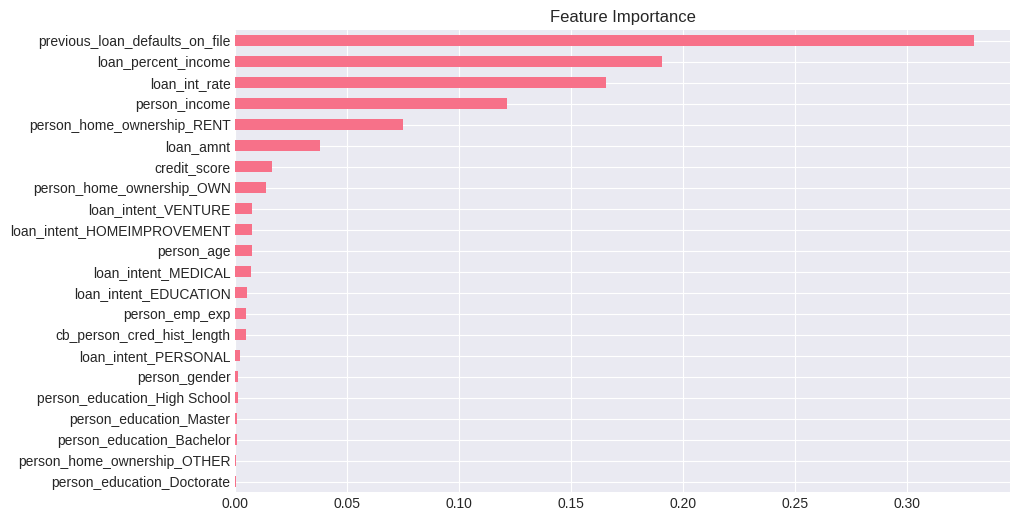

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()